# Fundamentos estadísticos del análisis de datos de vida

### Variables aleatorias · pdf y cdf · confiabilidad · tasa de fallas · distribuciones de vida

---

Este cuaderno recorre la cadena lógica completa del análisis de datos de vida: desde qué es una
variable aleatoria hasta cómo se derivan, **todas a partir de una sola función**, las cuatro
medidas que usa la ingeniería de confiabilidad.

La estructura sigue el desarrollo del *Life Data Analysis Reference* de ReliaSoft
([Basic Statistical Background](https://help.reliasoft.com/reference/life_data_analysis/lda/basic_statistical_background.html) ·
[Life Distributions](https://help.reliasoft.com/reference/life_data_analysis/lda/life_distributions.html)),
complementado con Meeker, Escobar y Pascual (2022) y el NIST/SEMATECH e-Handbook (2012).

### Contenido

| Sección | Tema |
|---|---|
| **1** | Variables aleatorias: discreta, continua y mixta |
| **2** | Función de densidad (pdf) y de distribución acumulada (cdf) |
| **3** | La relación cdf ↔ pdf: integral y derivada |
| **4** | Medidas de posición: por qué la media es sensible a los valores extremos |
| **5** | De la cdf a la función de confiabilidad $R(t)$ |
| **6** | La tasa de fallas $\lambda(t)$: la función condicional |
| **7** | Distribuciones de vida más usadas |
| **8** | Parámetros de escala, forma y localización |

### Convención de notación

Se usa la notación de ReliaSoft, estándar en la industria:

| Símbolo | Nombre | Equivalente estadístico |
|---|---|---|
| $f(t)$ | Función de densidad | pdf |
| $Q(t)$ | **Infiabilidad** — probabilidad de falla | cdf, $F(t)$ |
| $R(t)$ | **Confiabilidad** | Función de supervivencia, $S(t)$ |
| $\lambda(t)$ | **Tasa de fallas** | Función de riesgo, $h(t)$ |

> **Trazabilidad.** Todos los datos son simulados con parámetros declarados y semilla fija.
> Las fuentes respaldan los **métodos**, no los valores numéricos de los ejemplos.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, PercentFormatter
from scipy import stats, integrate

RNG = np.random.default_rng(20260912)

# ---------- Paleta y estilo editorial ----------
PAL = {
    "azul":    "#1F4E79",   # primario
    "celeste": "#2E86C1",
    "naranja": "#D1670B",
    "verde":   "#1E7B4F",
    "morado":  "#6C3483",
    "rojo":    "#A93226",
    "gris":    "#5D6D7E",
    "grisc":   "#AEB6BF",
    "fondo":   "#F4F7FA",
    "relleno": "#D6E4F0",
}
CICLO = [PAL["azul"], PAL["naranja"], PAL["verde"], PAL["morado"],
         PAL["celeste"], PAL["rojo"]]

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 130,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "font.size": 9.5,
    "axes.titlesize": 10.5, "axes.titleweight": "semibold", "axes.titlepad": 9,
    "axes.labelsize": 9.5, "axes.labelcolor": PAL["gris"],
    "axes.edgecolor": PAL["grisc"], "axes.linewidth": .9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": PAL["grisc"], "grid.alpha": .35, "grid.linewidth": .6,
    "xtick.color": PAL["gris"], "ytick.color": PAL["gris"],
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2.0, "lines.solid_capstyle": "round",
    "axes.prop_cycle": mpl.cycler(color=CICLO),
    "figure.constrained_layout.use": True,
})

def titulo(fig, texto, subtitulo=None):
    # Encabezado editorial: titulo en negrita + subtitulo gris, sin solaparse
    y_t = 1.12 if subtitulo else 1.06
    fig.suptitle(texto, fontsize=12.5, fontweight="bold",
                 color=PAL["azul"], ha="left", x=0.012, y=y_t)
    if subtitulo:
        fig.text(0.012, 1.035, subtitulo, fontsize=9,
                 color=PAL["gris"], ha="left", va="top")

def anota(ax, texto, xy, xytext, color=None):
    ax.annotate(texto, xy=xy, xytext=xytext, fontsize=8.2,
                color=color or PAL["gris"],
                arrowprops=dict(arrowstyle="->", color=color or PAL["gris"],
                                lw=.9, connectionstyle="arc3,rad=.2"))

def num(v, dec=2):
    # Formato decimal en español: separador coma
    return f"{v:,.{dec}f}".replace(",", "@").replace(".", ",").replace("@", ".")

pd.set_option("display.width", 130)
print(f"numpy {np.__version__} · scipy {__import__('scipy').__version__} · "
      f"matplotlib {mpl.__version__}")

numpy 2.4.6 · scipy 1.17.1 · matplotlib 3.11.1


---
## 1 · Variables aleatorias

### Definición

Una **variable aleatoria** es una función $X:\Omega \to \mathbb{R}$ que asigna un número real a
cada resultado del espacio muestral $\Omega$. No es "una variable que varía al azar": es una
**regla de medición** aplicada a un experimento cuyo resultado es incierto.

En confiabilidad, el experimento es *poner una unidad en operación* y la variable aleatoria es
la medida de interés. ReliaSoft plantea la distinción central: en el caso de tiempos hasta la
falla, la variable aleatoria es el tiempo hasta la falla del componente y puede tomar un número
infinito de valores posibles en el rango de 0 a infinito, dado que no conocemos *a priori* el
instante exacto de la falla ([ReliaSoft, *Basic Statistical Background*](https://help.reliasoft.com/reference/life_data_analysis/lda/basic_statistical_background.html)).

### Los tres tipos

| Tipo | Recorrido | Se describe con | Ejemplo en confiabilidad |
|---|---|---|---|
| **Discreta** | Conjunto numerable | Función de masa $p(x)=P(X=x)$ | ¿El componente está defectuoso? (0/1); número de fallas en un año |
| **Continua** | Intervalo no numerable | Densidad $f(t)$; $P(X=t)=0$ | Tiempo hasta la falla; duración de una reparación |
| **Mixta** | Átomos + parte continua | Descomposición de ambas | Vida de un ítem con fracción defectuosa de fábrica |

El mismo texto señala que al juzgar un componente como defectuoso o no defectuoso solo son
posibles dos resultados, y entonces la variable es **discreta**; mientras que el análisis de
vida trata casi exclusivamente con variables **continuas**.

El tercer tipo —**mixto**— es menos citado pero muy real en la práctica: aparece cuando una
fracción de las unidades falla en $t=0$ (defectos de fabricación, "dead on arrival") y el resto
tiene vida continua. Su cdf tiene un **salto** en el origen.

findfont: Failed to find font weight semibold, now using 700.


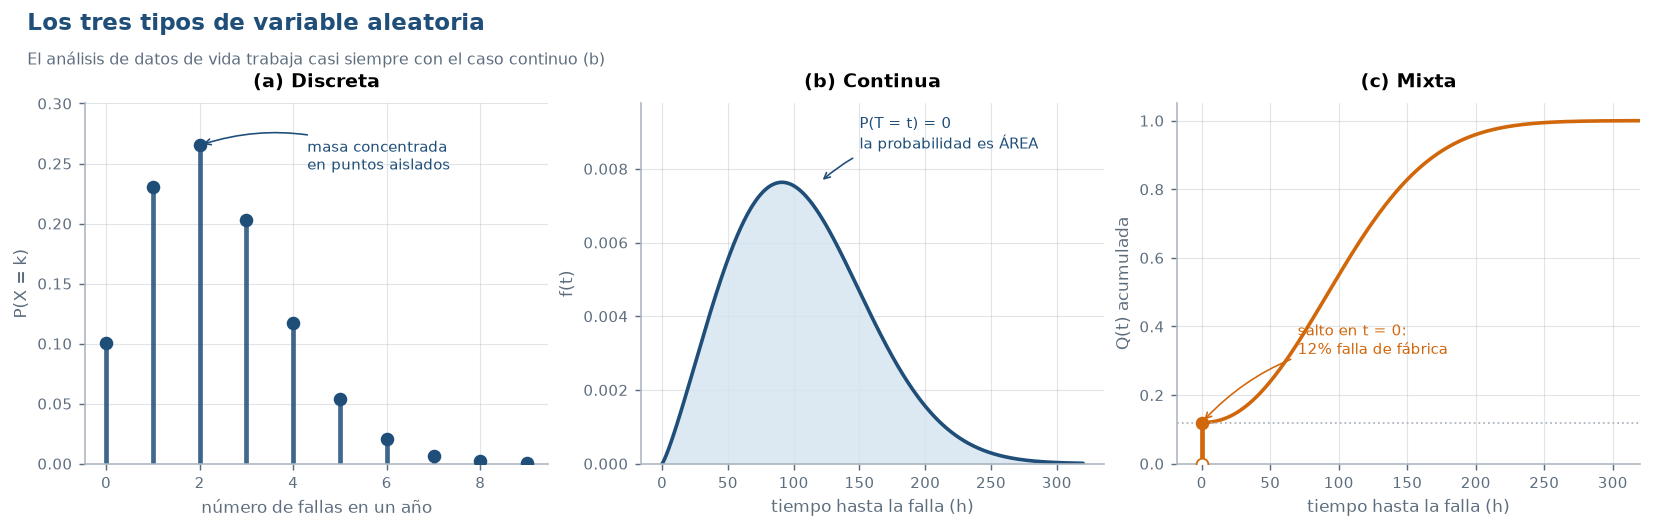

(a) Discreta   E[X] = 2.30 fallas/año   |   P(X = 2) = 0.2652
(b) Continua   P(T = 120 h) = 0 exactamente; P(110 < T < 130) = 0.1344
(c) Mixta      P(T = 0) = 0.12  (átomo)  +  0.88 de masa continua


In [2]:
fig, ax = plt.subplots(1, 3, figsize=(12.6, 3.5))

# ---------- (a) DISCRETA: número de fallas al año, Poisson(2.3)
mu = 2.3
k = np.arange(0, 10)
pk = stats.poisson.pmf(k, mu)
ax[0].vlines(k, 0, pk, color=PAL["azul"], lw=2.6, alpha=.85)
ax[0].plot(k, pk, "o", color=PAL["azul"], ms=6.5, zorder=3)
ax[0].set_title("(a) Discreta")
ax[0].set_xlabel("número de fallas en un año"); ax[0].set_ylabel("P(X = k)")
ax[0].xaxis.set_major_locator(MultipleLocator(2))
ax[0].set_ylim(0, .30)
anota(ax[0], "masa concentrada\nen puntos aislados", (2, pk[2]), (4.3, .245), PAL["azul"])

# ---------- (b) CONTINUA: tiempo hasta la falla, Weibull
t = np.linspace(0, 320, 500)
ft = stats.weibull_min.pdf(t, 2.2, scale=120)
ax[1].fill_between(t, ft, color=PAL["relleno"], alpha=.85)
ax[1].plot(t, ft, color=PAL["azul"])
ax[1].set_title("(b) Continua")
ax[1].set_xlabel("tiempo hasta la falla (h)"); ax[1].set_ylabel("f(t)")
ax[1].set_ylim(0, ft.max() * 1.28)
anota(ax[1], "P(T = t) = 0\nla probabilidad es ÁREA", (120, ft.max()),
      (150, ft.max() * 1.12), PAL["azul"])

# ---------- (c) MIXTA: 12 % defectuosa en t=0 + vida continua
p0 = 0.12
tt = np.linspace(0.1, 320, 500)
Fm = p0 + (1 - p0) * stats.weibull_min.cdf(tt, 2.2, scale=120)
ax[2].plot([0, 0], [0, p0], color=PAL["naranja"], lw=2.6)
ax[2].plot(0, p0, "o", color=PAL["naranja"], ms=6.5, zorder=3)
ax[2].plot(0, 0, "o", mfc="white", mec=PAL["naranja"], ms=6.5, zorder=3)
ax[2].plot(tt, Fm, color=PAL["naranja"])
ax[2].set_title("(c) Mixta")
ax[2].set_xlabel("tiempo hasta la falla (h)"); ax[2].set_ylabel("Q(t) acumulada")
ax[2].set_ylim(0, 1.05); ax[2].set_xlim(-18, 320)
ax[2].axhline(p0, ls=":", color=PAL["grisc"], lw=1)
anota(ax[2], f"salto en t = 0:\n{p0:.0%} falla de fábrica", (0, p0),
      (70, .32), PAL["naranja"])

titulo(fig, "Los tres tipos de variable aleatoria",
       "El análisis de datos de vida trabaja casi siempre con el caso continuo (b)")
plt.show()

print(f"(a) Discreta   E[X] = {mu:.2f} fallas/año   |   P(X = 2) = {stats.poisson.pmf(2, mu):.4f}")
print(f"(b) Continua   P(T = 120 h) = 0 exactamente; P(110 < T < 130) = "
      f"{stats.weibull_min.cdf(130, 2.2, scale=120) - stats.weibull_min.cdf(110, 2.2, scale=120):.4f}")
print(f"(c) Mixta      P(T = 0) = {p0:.2f}  (átomo)  +  {1-p0:.2f} de masa continua")

---
## 2 · Función de densidad (pdf) y función de distribución acumulada (cdf)

ReliaSoft lo plantea sin rodeos: la pdf y la cdf son dos de las funciones estadísticas más
importantes en confiabilidad y están estrechamente relacionadas; **cuando estas funciones se
conocen, casi cualquier otra medida de confiabilidad de interés puede derivarse u obtenerse**.

### Función de densidad de probabilidad

Si $T$ es continua, su densidad $f(t)$ cumple, para cualesquiera $a \le b$:

$$P(a \le T \le b)=\int_{a}^{b} f(t)\,dt$$

Es decir, **la probabilidad de que $T$ caiga en el intervalo $[a,b]$ es el área bajo la curva de
densidad entre $a$ y $b$**. La pdf representa la frecuencia relativa de los tiempos de falla en
función del tiempo.

Condiciones que debe cumplir toda densidad:

$$f(t)\ge 0 \quad \forall t, \qquad \int_{-\infty}^{\infty} f(t)\,dt = 1$$

Para las distribuciones de vida —con la excepción de la normal— el recorrido es $[0,\infty)$.

> **Advertencia de interpretación.** $f(t)$ **no es una probabilidad**. Tiene unidades de
> $1/\text{tiempo}$ y puede ser mayor que 1. La probabilidad aparece solo al integrar.

### Función de distribución acumulada

$$Q(t)=P(T\le t)=\int_{0}^{t} f(s)\,ds$$

El valor de un punto sobre la curva de la cdf representa el área bajo la curva **a la izquierda
de ese punto** en la pdf. En confiabilidad, la cdf mide la probabilidad de que el ítem falle
antes del tiempo $t$, y por eso se denomina también **infiabilidad** (*unreliability*).

Propiedades: $Q$ es no decreciente, continua por la derecha, $Q(0)=0$ y $Q(\infty)=1$.

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


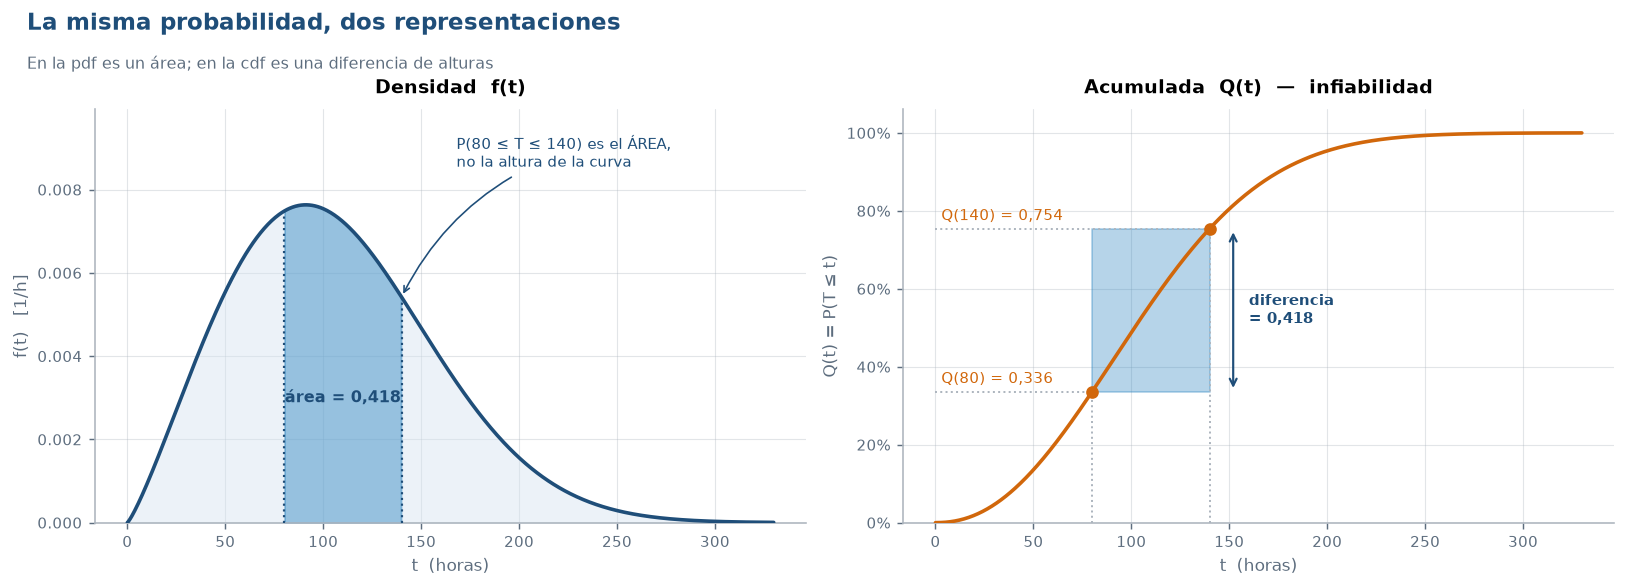

Área bajo f(t) entre 80 y 140 h  (integración numérica) = 0.418087
Q(140) − Q(80)                   (diferencia de la cdf) = 0.418087

Verificación de normalización:  ∫ f(t) dt de 0 a ∞ = 1.000000
Máximo de f(t) = 0.00763 1/h  ->  es una DENSIDAD, no una probabilidad


In [3]:
# Weibull beta=2,2  eta=120 h  como caso de referencia de todo el cuaderno
BETA, ETA = 2.2, 120.0
M = stats.weibull_min(BETA, scale=ETA)
t = np.linspace(0, 330, 700)

A, B = 80.0, 140.0                       # intervalo de interés
p_ab = M.cdf(B) - M.cdf(A)

fig, ax = plt.subplots(1, 2, figsize=(12.4, 3.9))

# ----- pdf con area sombreada
ax[0].plot(t, M.pdf(t), color=PAL["azul"], zorder=3)
m = (t >= A) & (t <= B)
ax[0].fill_between(t[m], M.pdf(t[m]), color=PAL["celeste"], alpha=.45, zorder=2)
ax[0].fill_between(t, M.pdf(t), color=PAL["relleno"], alpha=.45, zorder=1)
for v in (A, B):
    ax[0].vlines(v, 0, M.pdf(v), color=PAL["azul"], ls=":", lw=1.2, zorder=3)
ax[0].set_title("Densidad  f(t)")
ax[0].set_xlabel("t  (horas)"); ax[0].set_ylabel("f(t)   [1/h]")
ax[0].set_ylim(0, M.pdf(t).max() * 1.3)
ax[0].text((A + B) / 2, M.pdf((A + B) / 2) * .40,
           f"área = {num(p_ab,3)}", ha="center", fontsize=9,
           color=PAL["azul"], fontweight="semibold")
anota(ax[0], "P(80 ≤ T ≤ 140) es el ÁREA,\nno la altura de la curva",
      (B, M.pdf(B)), (168, M.pdf(t).max() * 1.12), PAL["azul"])

# ----- cdf con el mismo intervalo como diferencia de alturas
ax[1].plot(t, M.cdf(t), color=PAL["naranja"], zorder=3)
ax[1].fill_between([A, B], [M.cdf(A)] * 2, [M.cdf(B)] * 2,
                   color=PAL["celeste"], alpha=.35)
for v, lab in ((A, "Q(80)"), (B, "Q(140)")):
    ax[1].hlines(M.cdf(v), 0, v, color=PAL["grisc"], ls=":", lw=1.1)
    ax[1].vlines(v, 0, M.cdf(v), color=PAL["grisc"], ls=":", lw=1.1)
    ax[1].plot(v, M.cdf(v), "o", color=PAL["naranja"], ms=6, zorder=4)
    ax[1].text(3, M.cdf(v) + .022, f"{lab} = {num(M.cdf(v),3)}", fontsize=8.3,
               color=PAL["naranja"])
ax[1].annotate("", xy=(B + 12, M.cdf(B)), xytext=(B + 12, M.cdf(A)),
               arrowprops=dict(arrowstyle="<->", color=PAL["azul"], lw=1.2))
ax[1].text(B + 20, (M.cdf(A) + M.cdf(B)) / 2,
           f"diferencia\n= {num(p_ab,3)}", fontsize=8.3, color=PAL["azul"],
           va="center", fontweight="semibold")
ax[1].set_title("Acumulada  Q(t)  —  infiabilidad")
ax[1].set_xlabel("t  (horas)"); ax[1].set_ylabel("Q(t) = P(T ≤ t)")
ax[1].set_ylim(0, 1.06)
ax[1].yaxis.set_major_formatter(PercentFormatter(1.0))

titulo(fig, "La misma probabilidad, dos representaciones",
       "En la pdf es un área; en la cdf es una diferencia de alturas")
plt.show()

area_num, _ = integrate.quad(M.pdf, A, B)
print(f"Área bajo f(t) entre 80 y 140 h  (integración numérica) = {area_num:.6f}")
print(f"Q(140) − Q(80)                   (diferencia de la cdf) = {p_ab:.6f}")
print(f"\nVerificación de normalización:  ∫ f(t) dt de 0 a ∞ = "
      f"{integrate.quad(M.pdf, 0, np.inf)[0]:.6f}")
print(f"Máximo de f(t) = {M.pdf(t).max():.5f} 1/h  ->  es una DENSIDAD, no una probabilidad")

---
## 3 · La relación entre pdf y cdf

Las dos funciones contienen exactamente la misma información. Están ligadas por el **teorema
fundamental del cálculo**:

$$\boxed{\;Q(t)=\int_{0}^{t} f(s)\,ds \qquad \Longleftrightarrow \qquad f(t)=\frac{d\,Q(t)}{dt}\;}$$

donde $s$ es una variable muda de integración. En palabras:

- **La cdf es el área acumulada bajo la pdf.** Integrar la densidad hasta $t$ da la probabilidad
  de haber fallado antes de $t$.
- **La pdf es la pendiente de la cdf.** Donde la cdf sube más rápido, la densidad es mayor: ahí
  se concentran las fallas.

Dos consecuencias visuales que conviene reconocer en cualquier gráfica:

1. El **máximo de la pdf** (la moda) coincide con el **punto de inflexión de la cdf**, donde la
   pendiente es máxima.
2. Donde la pdf se acerca a cero, la cdf se **aplana**.

Verifiquemos ambas afirmaciones numéricamente —derivando e integrando la curva real— en lugar
de afirmarlas.

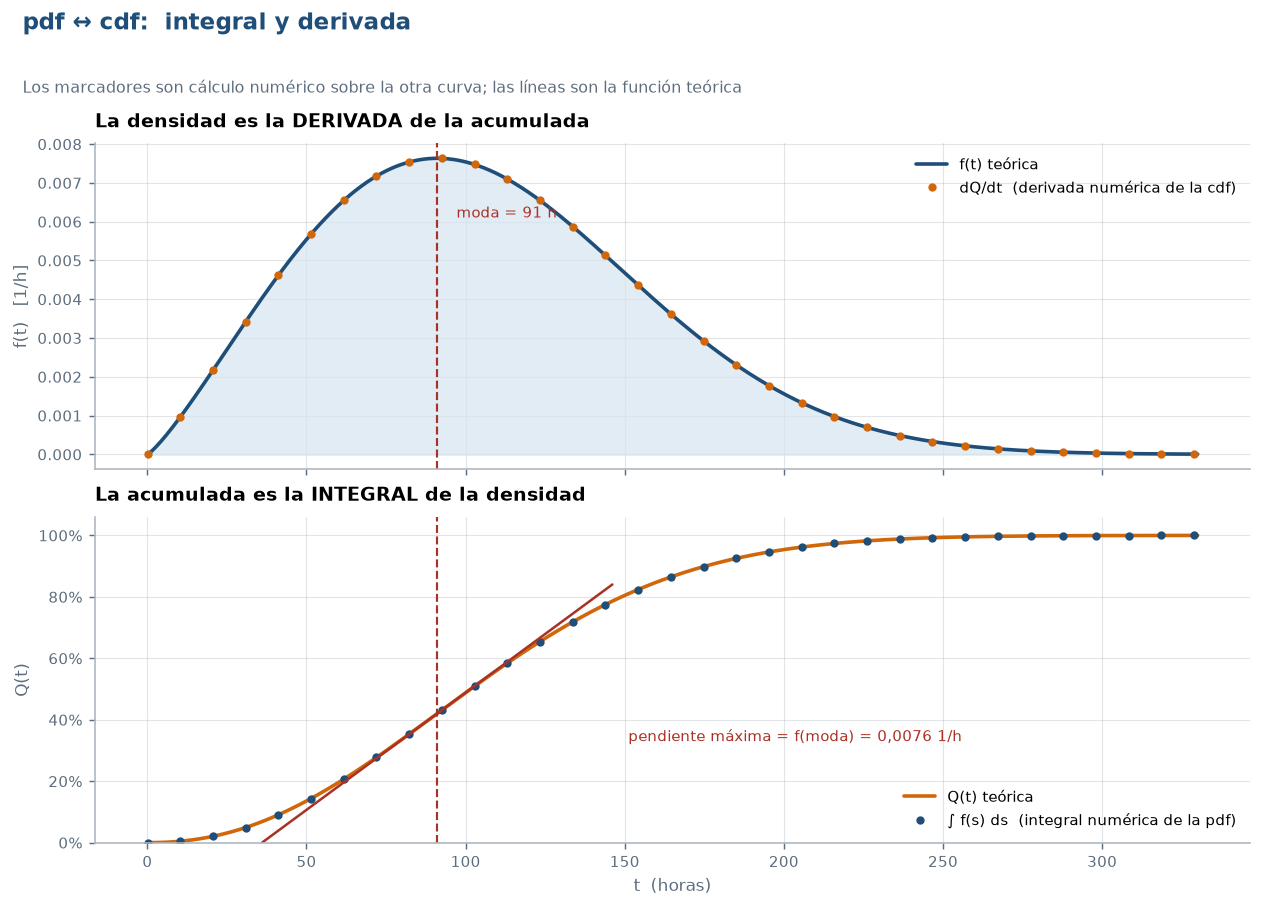

Error máximo al integrar la pdf y comparar con la cdf : 1.33e-06
Error máximo al derivar la cdf y comparar con la pdf  : 8.89e-06

Moda teórica  η·((β−1)/β)^(1/β) = 91.10 h
Máximo numérico de la pdf        = 91.07 h
Máximo numérico de dQ/dt         = 91.07 h   <- coinciden


In [4]:
t = np.linspace(0.05, 330, 900)
f_teo = M.pdf(t)
Q_teo = M.cdf(t)

# (1) INTEGRAR la pdf -> debe reproducir la cdf
Q_num = integrate.cumulative_trapezoid(f_teo, t, initial=0)

# (2) DERIVAR la cdf -> debe reproducir la pdf
f_num = np.gradient(Q_teo, t)

moda = ETA * ((BETA - 1) / BETA) ** (1 / BETA)      # moda teórica de la Weibull

fig, ax = plt.subplots(2, 1, figsize=(9.6, 6.1), sharex=True,
                       gridspec_kw={"height_ratios": [1, 1]})

# ---- panel superior: pdf
ax[0].fill_between(t, f_teo, color=PAL["relleno"], alpha=.7)
ax[0].plot(t, f_teo, color=PAL["azul"], label="f(t) teórica")
ax[0].plot(t[::28], f_num[::28], "o", ms=3.6, color=PAL["naranja"],
           label="dQ/dt  (derivada numérica de la cdf)")
ax[0].axvline(moda, color=PAL["rojo"], ls="--", lw=1.2)
ax[0].set_ylabel("f(t)   [1/h]"); ax[0].legend(loc="upper right")
ax[0].set_title("La densidad es la DERIVADA de la acumulada", loc="left")
ax[0].text(moda + 6, f_teo.max() * .80, f"moda = {moda:.0f} h",
           color=PAL["rojo"], fontsize=8.4)

# ---- panel inferior: cdf
ax[1].plot(t, Q_teo, color=PAL["naranja"], label="Q(t) teórica")
ax[1].plot(t[::28], Q_num[::28], "o", ms=3.6, color=PAL["azul"],
           label="∫ f(s) ds  (integral numérica de la pdf)")
ax[1].axvline(moda, color=PAL["rojo"], ls="--", lw=1.2)
# recta tangente en la moda: su pendiente es f(moda)
pend = M.pdf(moda)
xs = np.linspace(moda - 55, moda + 55, 10)
ax[1].plot(xs, M.cdf(moda) + pend * (xs - moda), color=PAL["rojo"], lw=1.4, ls="-")
ax[1].text(moda + 60, M.cdf(moda) - .09,
           f"pendiente máxima = f(moda) = {num(pend,4)} 1/h",
           color=PAL["rojo"], fontsize=8.4)
ax[1].set_xlabel("t  (horas)"); ax[1].set_ylabel("Q(t)")
ax[1].set_ylim(0, 1.06); ax[1].legend(loc="lower right")
ax[1].yaxis.set_major_formatter(PercentFormatter(1.0))
ax[1].set_title("La acumulada es la INTEGRAL de la densidad", loc="left")

titulo(fig, "pdf ↔ cdf:  integral y derivada",
       "Los marcadores son cálculo numérico sobre la otra curva; las líneas son la función teórica")
plt.show()

print(f"Error máximo al integrar la pdf y comparar con la cdf : {np.abs(Q_num - Q_teo).max():.2e}")
print(f"Error máximo al derivar la cdf y comparar con la pdf  : {np.abs(f_num - f_teo).max():.2e}")
print(f"\nModa teórica  η·((β−1)/β)^(1/β) = {moda:.2f} h")
print(f"Máximo numérico de la pdf        = {t[np.argmax(f_teo)]:.2f} h")
print(f"Máximo numérico de dQ/dt         = {t[np.argmax(f_num)]:.2f} h   <- coinciden")

---
## 4 · Medidas de posición: la media es sensible a los valores extremos

Antes de seguir con las funciones de confiabilidad, conviene fijar una idea que cambia
decisiones reales. Las tres medidas de posición responden preguntas distintas:

$$\mu=E[T]=\int_{0}^{\infty} t\,f(t)\,dt \qquad
\tilde{t}: \; Q(\tilde{t})=0{,}5 \qquad
\text{moda}: \; \arg\max_t f(t)$$

La media es el **centro de masa** de la distribución: el punto donde la densidad se equilibraría
si fuera una placa física. Por eso un solo valor muy grande la desplaza —tiene **punto de
ruptura cero**—, mientras que la mediana solo se mueve un lugar en el orden.

### Demostración didáctica: el balancín

La analogía física es exacta. Si la densidad fuera una placa, la media es el punto de apoyo que
la equilibra. Un dato lejano actúa como un peso en el extremo de una palanca larga: **su efecto
es proporcional a la distancia**.

findfont: Failed to find font weight semibold, now using 700.


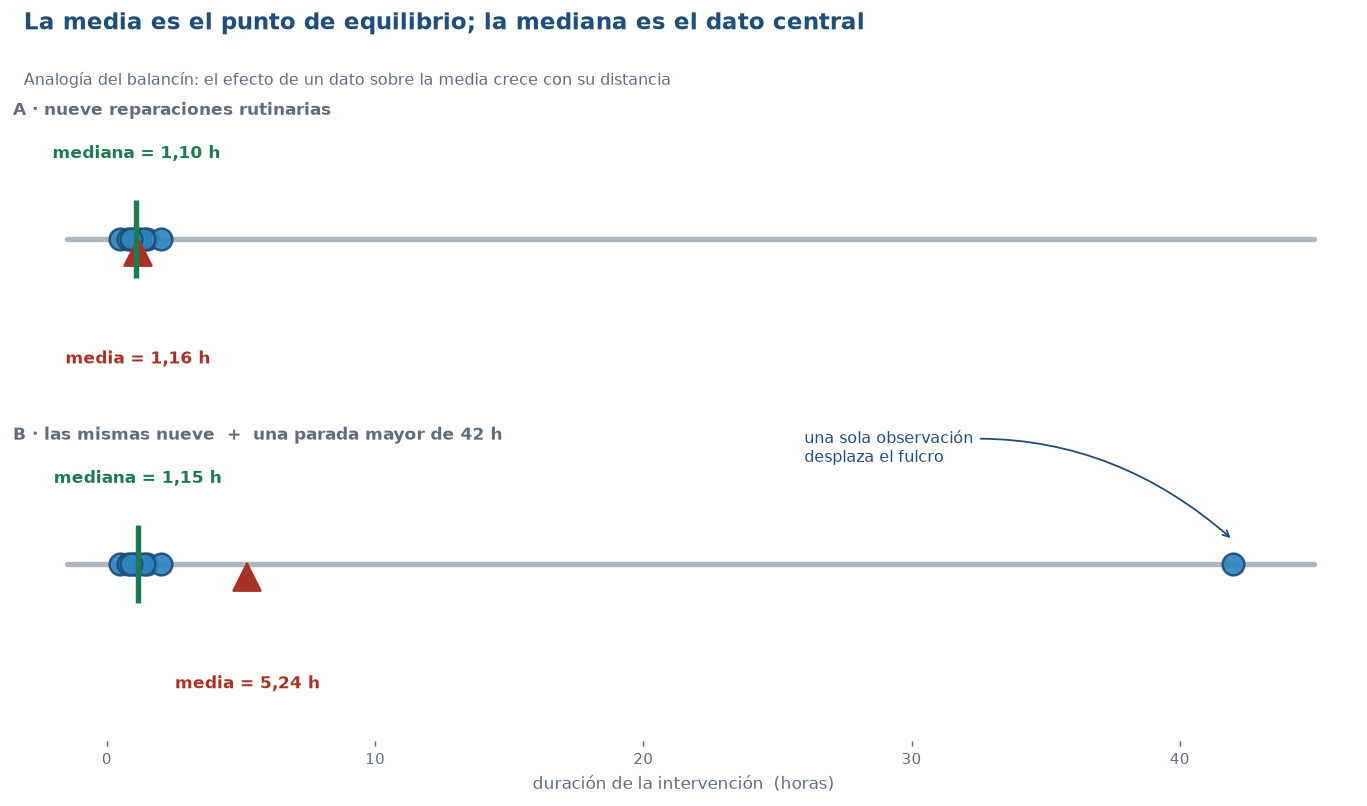

,n,media,mediana,desv. est.,rango
sin la parada mayor,9,1.16,1.10,0.44,1.5
con la parada mayor,10,5.24,1.15,12.92,41.5


La media se multiplica por 4.5  y la desviación estándar por 29.
La mediana pasa de 1.10 a 1.15 h.


In [5]:
# Nueve reparaciones rutinarias + una parada mayor
base = np.array([1.0, 0.5, 1.5, 2.0, 1.2, 0.8, 1.1, 1.4, 0.9])
extremo = 42.0
con = np.append(base, extremo)

fig, ax = plt.subplots(2, 1, figsize=(10.4, 5.4))

for a, x, nom in [(ax[0], base, "A · nueve reparaciones rutinarias"),
                  (ax[1], con,  "B · las mismas nueve  +  una parada mayor de 42 h")]:
    med, mdn = x.mean(), np.median(x)

    # viga del balancín
    a.hlines(0, -1.5, 45, color=PAL["grisc"], lw=3, zorder=1,
             capstyle="round")
    # observaciones
    a.plot(x, np.zeros_like(x), "o", ms=12, color=PAL["celeste"],
           mec=PAL["azul"], mew=1.4, zorder=3, alpha=.92)

    # fulcro triangular relleno en la media
    a.plot(med, -.10, marker="^", ms=16, color=PAL["rojo"],
           mec=PAL["rojo"], zorder=4, clip_on=False)
    a.vlines(med, -.10, 0, color=PAL["rojo"], lw=1.2, zorder=2)

    # marca de la mediana
    a.vlines(mdn, -.30, .30, color=PAL["verde"], lw=3, zorder=5)

    # etiquetas en caja, ancladas dentro del eje
    a.text(med, -.95, f"media = {num(med)} h", color=PAL["rojo"], ha="center",
           fontsize=9.5, fontweight="semibold",
           bbox=dict(fc="white", ec="none", pad=1.5))
    a.text(mdn, .62, f"mediana = {num(mdn)} h", color=PAL["verde"], ha="center",
           fontsize=9.5, fontweight="semibold",
           bbox=dict(fc="white", ec="none", pad=1.5))

    a.set_xlim(-3.5, 46.5); a.set_ylim(-1.35, 1.05)
    a.set_yticks([]); a.grid(False)
    for lado in ("left", "right", "top", "bottom"):
        a.spines[lado].set_visible(False)
    a.text(0.0, 1.0, nom, transform=a.transAxes, fontsize=9.5,
           color=PAL["gris"], fontweight="semibold", va="top")

ax[0].set_xticks([])
ax[1].set_xticks([0, 10, 20, 30, 40])
ax[1].tick_params(axis="x", length=3)
ax[1].set_xlabel("duración de la intervención  (horas)")
ax[1].annotate("una sola observación\ndesplaza el fulcro", xy=(extremo, .18),
               xytext=(26, .78), fontsize=8.6, color=PAL["azul"],
               arrowprops=dict(arrowstyle="->", color=PAL["azul"], lw=1,
                               connectionstyle="arc3,rad=-.25"))

titulo(fig, "La media es el punto de equilibrio; la mediana es el dato central",
       "Analogía del balancín: el efecto de un dato sobre la media crece con su distancia")
plt.show()

tab = pd.DataFrame({
    "n":        [len(base), len(con)],
    "media":    [base.mean(), con.mean()],
    "mediana":  [np.median(base), np.median(con)],
    "desv. est.": [base.std(ddof=1), con.std(ddof=1)],
    "rango":    [np.ptp(base), np.ptp(con)],
}, index=["sin la parada mayor", "con la parada mayor"])
display(tab.round(2))

print(f"La media se multiplica por {con.mean()/base.mean():.1f}  "
      f"y la desviación estándar por {con.std(ddof=1)/base.std(ddof=1):.0f}.")
print(f"La mediana pasa de {np.median(base):.2f} a {np.median(con):.2f} h.")

### Cuánto se necesita para mover cada medida

El concepto formal es el **punto de ruptura**: la fracción de datos que hay que corromper para
llevar el estimador a un valor arbitrario.

- **Media:** punto de ruptura $0\,\%$ — basta **una** observación.
- **Mediana:** punto de ruptura $50\,\%$ — hace falta corromper la mitad de la muestra.

Lo verificamos empujando un solo dato hacia el infinito.

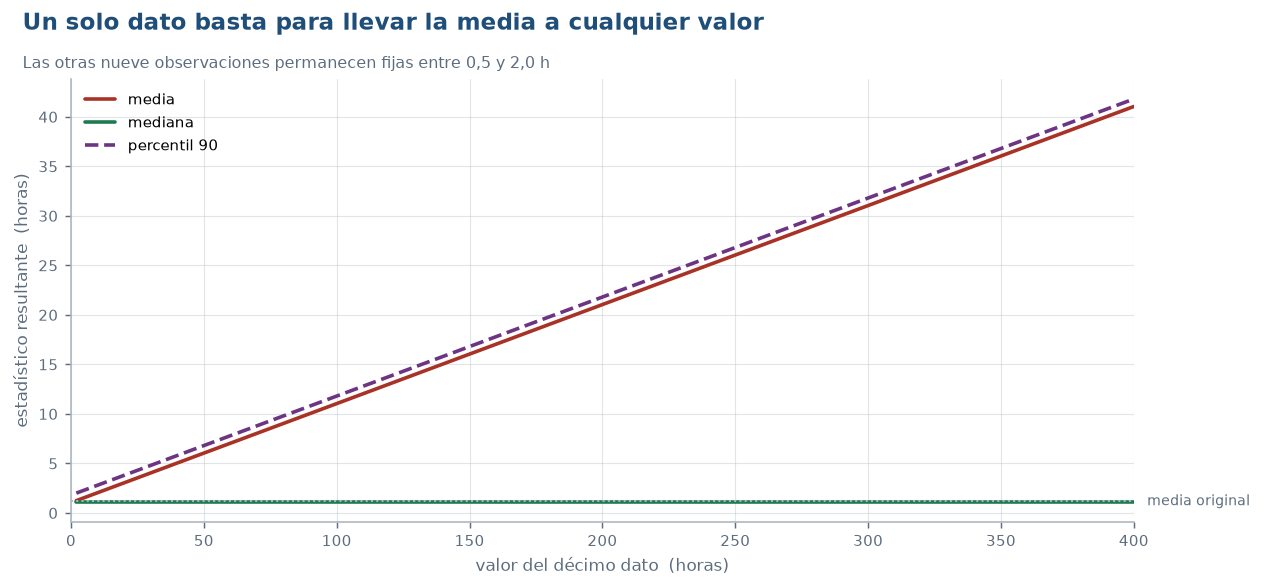

   décimo dato |   media |  mediana |     P90
----------------------------------------------
             2 |    1.24 |     1.15 |    2.00
            20 |    3.04 |     1.15 |    3.80
           100 |   11.04 |     1.15 |   11.80
           400 |   41.04 |     1.15 |   41.80
        10,000 | 1001.04 |     1.15 | 1001.80

La mediana NO se mueve más allá de 1,20 h: está protegida por el orden.


In [6]:
valores = np.linspace(2, 400, 260)
medias   = [np.append(base, v).mean()      for v in valores]
medianas = [np.median(np.append(base, v))  for v in valores]
p90      = [np.percentile(np.append(base, v), 90) for v in valores]

fig, ax = plt.subplots(figsize=(9.6, 3.9))
ax.plot(valores, medias,   color=PAL["rojo"],  label="media")
ax.plot(valores, medianas, color=PAL["verde"], label="mediana")
ax.plot(valores, p90,      color=PAL["morado"], ls="--", label="percentil 90")
ax.axhline(base.mean(), color=PAL["grisc"], ls=":", lw=1.1)
ax.text(405, base.mean(), "media original", fontsize=8, color=PAL["gris"], va="center")
ax.set_xlabel("valor del décimo dato  (horas)")
ax.set_ylabel("estadístico resultante  (horas)")
ax.set_xlim(0, 400); ax.legend(loc="upper left")

titulo(fig, "Un solo dato basta para llevar la media a cualquier valor",
       "Las otras nueve observaciones permanecen fijas entre 0,5 y 2,0 h")
plt.show()

print(f"{'décimo dato':>14} | {'media':>7} | {'mediana':>8} | {'P90':>7}")
print("-" * 46)
for v in (2, 20, 100, 400, 10_000):
    s = np.append(base, v)
    print(f"{v:>14,.0f} | {s.mean():>7.2f} | {np.median(s):>8.2f} | "
          f"{np.percentile(s, 90):>7.2f}")
print("\nLa mediana NO se mueve más allá de 1,20 h: está protegida por el orden.")

### Qué reportar, según la decisión

Ninguna medida es "mejor": responden preguntas diferentes. El error es reportar una sola.

| Decisión | Medida adecuada | Por qué |
|---|---|---|
| Presupuestar horas-hombre del año | **Media** × número de eventos | El total es lo que se paga; la media lo reconstruye |
| Describir una intervención típica | **Mediana** + rango intercuartílico | No la arrastra la parada excepcional |
| Dimensionar personal para el peor caso | **Percentil 90 o 95** | La decisión vive en la cola |
| Fijar un intervalo de reemplazo | **Percentil bajo** ($B_{10}$, $B_1$) | La media deja fallar a la mayoría antes |

Y siempre: **$n$, unidad y ventana de observación**. Un promedio sin esos tres datos no es
auditable.

---
## 5 · De la cdf a la función de confiabilidad

Aquí se produce el paso conceptual que define la disciplina. La cdf responde *"¿cuál es la
probabilidad de que ya haya fallado?"*. La ingeniería de confiabilidad prefiere la pregunta
complementaria: *"¿cuál es la probabilidad de que **siga funcionando**?"*.

Como una unidad solo puede estar en dos estados mutuamente excluyentes y exhaustivos —operando o
fallada— las probabilidades suman uno:

$$Q(t) + R(t) = 1$$

de donde se obtiene la **función de confiabilidad**:

$$\boxed{\;R(t)=1-Q(t)=P(T>t)=\int_{t}^{\infty} f(s)\,ds\;}$$

Las tres expresiones son equivalentes: uno menos la infiabilidad, la probabilidad de sobrevivir
más allá de $t$, o el área bajo la densidad **a la derecha** de $t$.

### Propiedades

| Propiedad | Significado |
|---|---|
| $R(0)=1$ | Toda unidad está operativa al inicio (si no hay fracción defectuosa) |
| $R(\infty)=0$ | Toda unidad falla eventualmente |
| $R$ es monótona no creciente | La confiabilidad nunca aumenta con el tiempo |
| $f(t)=-\dfrac{dR(t)}{dt}$ | La densidad es la tasa de caída de la confiabilidad |

### La confiabilidad exige declarar un tiempo

Un valor de confiabilidad **sin un tiempo asociado no significa nada**. La especificación
correcta tiene la forma *"95 % de confiabilidad a 100 horas"*. Esto hace de $R(t)$ una
especificación mucho más informativa que el MTTF, que es un solo punto resumido de toda la
curva.

### El MTTF como área bajo la curva

$$\text{MTTF}=E[T]=\int_{0}^{\infty} t\,f(t)\,dt=\int_{0}^{\infty} R(t)\,dt$$

La segunda igualdad es notable: **el tiempo medio hasta la falla es el área bajo la curva de
confiabilidad**. La verificamos numéricamente.

findfont: Failed to find font weight semibold, now using 700.


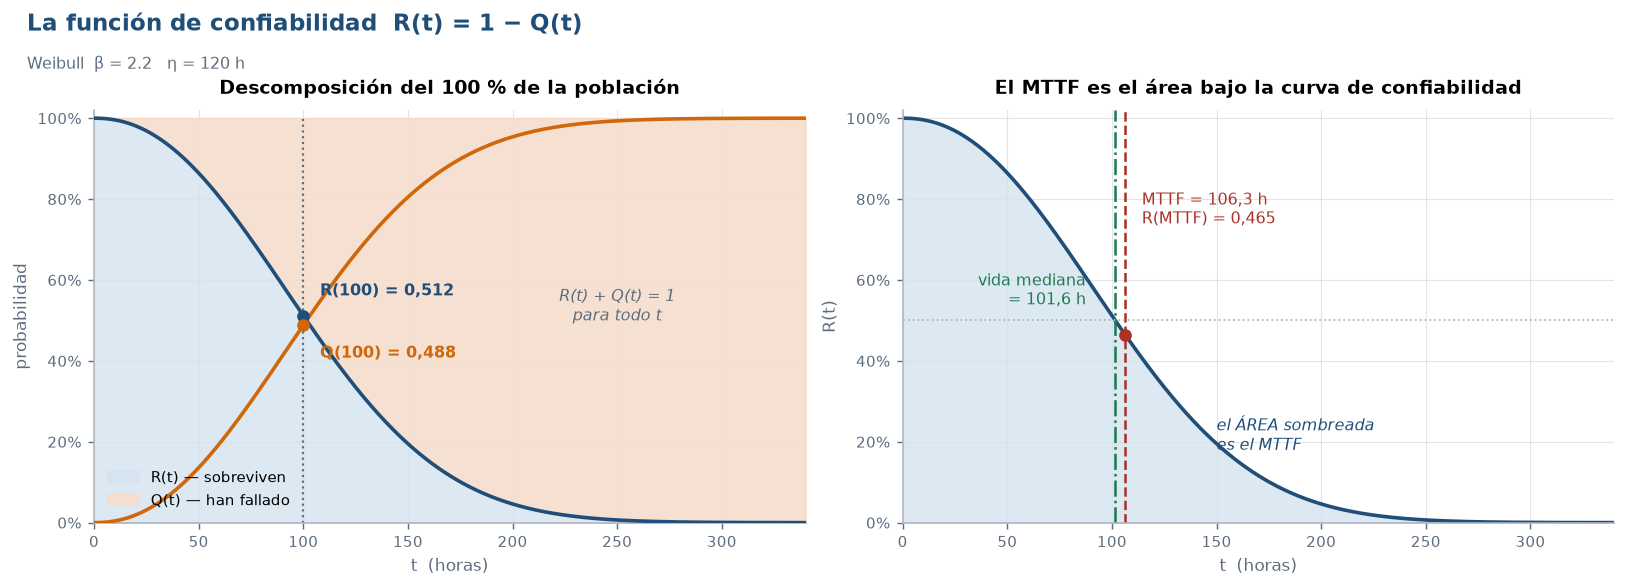

∫ R(t) dt de 0 a ∞      = 106.2750 h
E[T] = ∫ t·f(t) dt      = 106.2750 h      <- coinciden

R(MTTF) = 0.4651  ->  el 53.5% de las unidades YA FALLÓ al llegar al MTTF.
Vida mediana = 101.6 h  <  MTTF = 106.3 h

Por eso 'R = 95 % a 100 h' es una especificación útil y 'MTTF = 106 h' no lo es:
el MTTF resume toda la curva en un punto y oculta dónde ocurren las fallas.


In [7]:
t = np.linspace(0, 340, 800)
R = M.sf(t); Q = M.cdf(t)
MTTF = M.mean()

fig, ax = plt.subplots(1, 2, figsize=(12.4, 3.9))

# ----- (a) Q + R = 1
ax[0].fill_between(t, 0, R, color=PAL["relleno"], alpha=.85, label="R(t) — sobreviven")
ax[0].fill_between(t, R, 1, color="#F6DDCC", alpha=.9, label="Q(t) — han fallado")
ax[0].plot(t, R, color=PAL["azul"], zorder=3)
ax[0].plot(t, Q, color=PAL["naranja"], zorder=3)
T0 = 100.0
ax[0].vlines(T0, 0, 1, color=PAL["gris"], ls=":", lw=1.2)
ax[0].plot([T0, T0], [M.sf(T0), M.cdf(T0)], lw=0)
ax[0].plot(T0, M.sf(T0), "o", color=PAL["azul"], ms=6, zorder=4)
ax[0].plot(T0, M.cdf(T0), "o", color=PAL["naranja"], ms=6, zorder=4)
ax[0].text(T0 + 8, M.sf(T0) + .05, f"R(100) = {num(M.sf(T0),3)}", color=PAL["azul"],
           fontsize=8.6, fontweight="semibold")
ax[0].text(T0 + 8, M.cdf(T0) - .08, f"Q(100) = {num(M.cdf(T0),3)}", color=PAL["naranja"],
           fontsize=8.6, fontweight="semibold")
ax[0].text(250, .5, "R(t) + Q(t) = 1\npara todo t", fontsize=9, ha="center",
           color=PAL["gris"], style="italic")
ax[0].set_xlabel("t  (horas)"); ax[0].set_ylabel("probabilidad")
ax[0].set_ylim(0, 1.02); ax[0].set_xlim(0, 340)
ax[0].yaxis.set_major_formatter(PercentFormatter(1.0))
ax[0].legend(loc="lower left")
ax[0].set_title("Descomposición del 100 % de la población")

# ----- (b) MTTF = área bajo R(t)
ax[1].fill_between(t, R, color=PAL["relleno"], alpha=.85)
ax[1].plot(t, R, color=PAL["azul"])
ax[1].axvline(MTTF, color=PAL["rojo"], ls="--", lw=1.4)
ax[1].plot(MTTF, M.sf(MTTF), "o", color=PAL["rojo"], ms=6, zorder=4)
ax[1].axvline(M.median(), color=PAL["verde"], ls="-.", lw=1.4)
ax[1].axhline(.5, color=PAL["grisc"], ls=":", lw=1)
ax[1].text(MTTF + 8, .82, f"MTTF = {num(MTTF,1)} h\nR(MTTF) = {num(M.sf(MTTF),3)}",
           color=PAL["rojo"], fontsize=8.6, va="top")
ax[1].text(M.median() - 14, .62, f"vida mediana\n= {num(M.median(),1)} h",
           color=PAL["verde"], fontsize=8.6, ha="right", va="top")
ax[1].text(150, .18, "el ÁREA sombreada\nes el MTTF", fontsize=9,
           color=PAL["azul"], style="italic")
ax[1].set_xlabel("t  (horas)"); ax[1].set_ylabel("R(t)")
ax[1].set_ylim(0, 1.02); ax[1].set_xlim(0, 340)
ax[1].yaxis.set_major_formatter(PercentFormatter(1.0))
ax[1].set_title("El MTTF es el área bajo la curva de confiabilidad")

titulo(fig, "La función de confiabilidad  R(t) = 1 − Q(t)",
       f"Weibull  β = {BETA}   η = {ETA:.0f} h")
plt.show()

area_R = integrate.quad(M.sf, 0, np.inf)[0]
print(f"∫ R(t) dt de 0 a ∞      = {area_R:.4f} h")
print(f"E[T] = ∫ t·f(t) dt      = {MTTF:.4f} h      <- coinciden\n")
print(f"R(MTTF) = {M.sf(MTTF):.4f}  ->  el {M.cdf(MTTF):.1%} de las unidades YA FALLÓ "
      f"al llegar al MTTF.")
print(f"Vida mediana = {M.median():.1f} h  <  MTTF = {MTTF:.1f} h")
print("\nPor eso 'R = 95 % a 100 h' es una especificación útil y 'MTTF = 106 h' no lo es:")
print("el MTTF resume toda la curva en un punto y oculta dónde ocurren las fallas.")

---
## 6 · La tasa de fallas: la función condicional

La densidad $f(t)$ mira la población **original**. Pero al decidir si mantener, intervenir o
reemplazar un equipo, la población relevante es otra: **las unidades que siguen operando hoy**.
Esa es la pregunta que responde la tasa de fallas.

### Construcción

La probabilidad de fallar en $(t, t+\Delta t]$ **dado que se llegó vivo a $t$** es:

$$P(t<T\le t+\Delta t \mid T>t)=\frac{P(t<T\le t+\Delta t)}{P(T>t)}=\frac{f(t)\,\Delta t}{R(t)}$$

Dividiendo por $\Delta t$ y tomando el límite se obtiene la **tasa de fallas instantánea**:

$$\boxed{\;\lambda(t)=\lim_{\Delta t\to 0}\frac{P(t<T\le t+\Delta t\mid T>t)}{\Delta t}
=\frac{f(t)}{R(t)}\;}$$

### Las relaciones que cierran el sistema

Como $f(t)=-dR/dt$, se sigue que

$$\lambda(t)=-\frac{d}{dt}\ln R(t) \qquad\Longrightarrow\qquad
R(t)=\exp\!\left(-\int_{0}^{t}\lambda(s)\,ds\right)=e^{-\Lambda(t)}$$

donde $\Lambda(t)=\int_0^t \lambda(s)\,ds$ es la **tasa de fallas acumulada**. Esto completa el
círculo: **conocida cualquiera de las cuatro funciones, las otras tres quedan determinadas**.

| Se conoce | $f(t)$ | $Q(t)$ | $R(t)$ | $\lambda(t)$ |
|---|---|---|---|---|
| $f$ | — | $\int_0^t f$ | $\int_t^\infty f$ | $f/R$ |
| $Q$ | $dQ/dt$ | — | $1-Q$ | $Q'/(1-Q)$ |
| $R$ | $-dR/dt$ | $1-R$ | — | $-\,d\ln R/dt$ |
| $\lambda$ | $\lambda e^{-\Lambda}$ | $1-e^{-\Lambda}$ | $e^{-\Lambda}$ | — |

> **$\lambda(t)$ no es una probabilidad.** Tiene unidades de $1/\text{tiempo}$ y puede superar 1.
> La probabilidad aproximada es $\lambda(t)\,\Delta t$ para $\Delta t$ pequeño. Confundir tasa de
> fallas con probabilidad de falla es uno de los errores más costosos del análisis de
> confiabilidad.

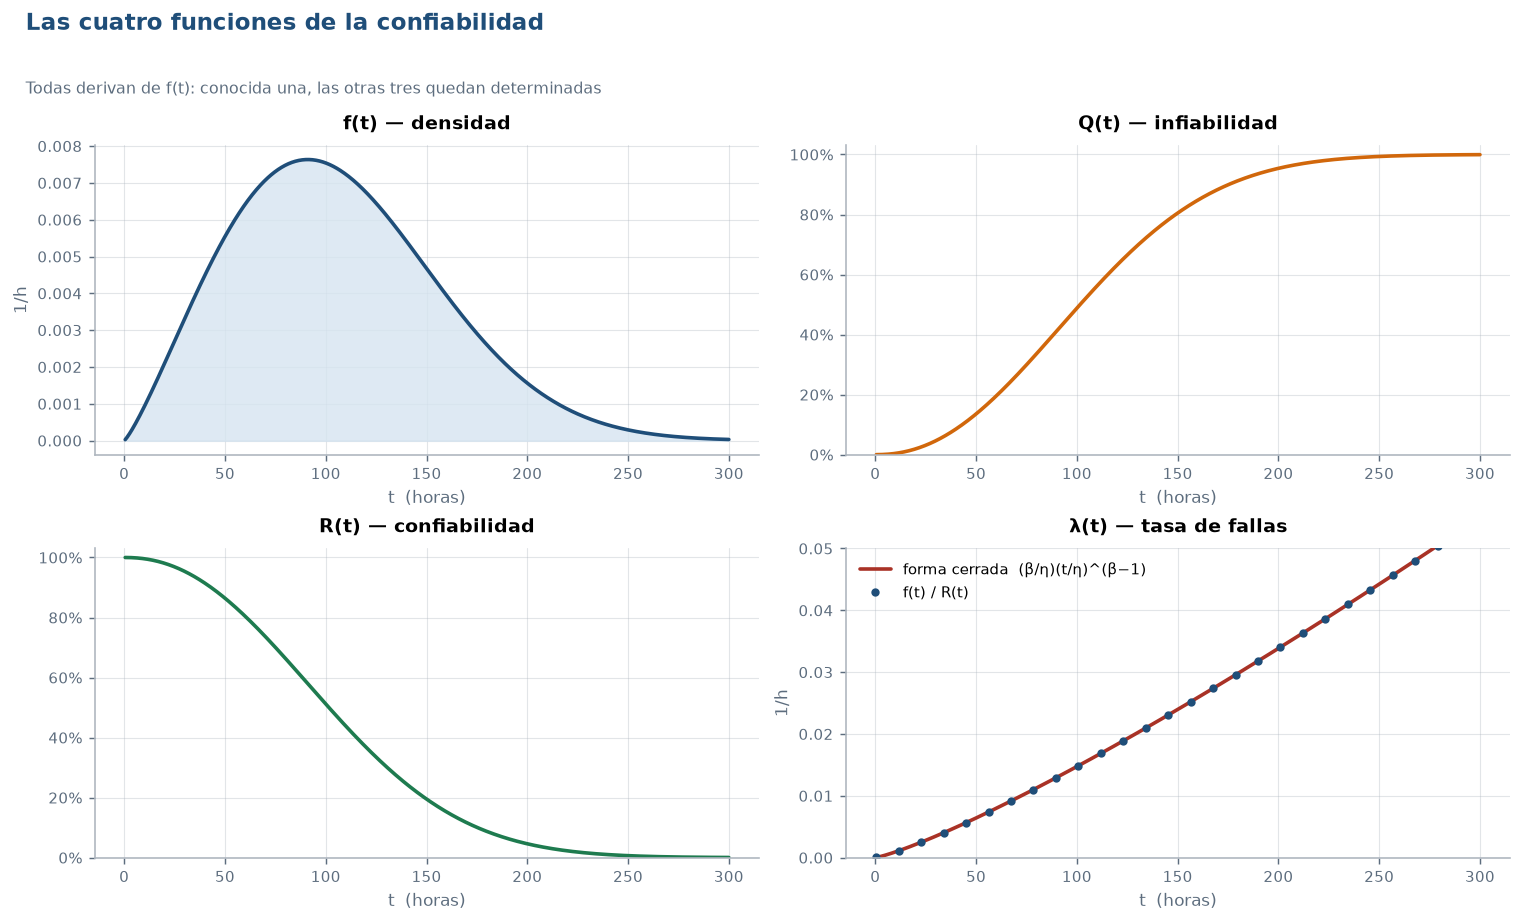

Error máximo entre  f(t)/R(t)  y la fórmula cerrada: 1.39e-17

Error máximo al reconstruir R(t) = exp(−∫λ(s)ds): 1.22e-06

--- λ(t) NO es una probabilidad ---
  λ( 50 h) = 0.00641 1/h  ->  P(falla en la próxima hora | vivo a 50 h) ≈ 0.00641
  λ(150 h) = 0.02396 1/h  ->  P(falla en la próxima hora | vivo a 150 h) ≈ 0.02396
  λ(250 h) = 0.04423 1/h  ->  P(falla en la próxima hora | vivo a 250 h) ≈ 0.04423


In [8]:
t = np.linspace(0.5, 300, 700)
f_t, R_t, Q_t = M.pdf(t), M.sf(t), M.cdf(t)
lam = f_t / R_t
lam_teo = (BETA / ETA) * (t / ETA) ** (BETA - 1)     # forma cerrada Weibull

fig, ax = plt.subplots(2, 2, figsize=(11.6, 6.2))
ax = ax.ravel()

ax[0].fill_between(t, f_t, color=PAL["relleno"], alpha=.8)
ax[0].plot(t, f_t, color=PAL["azul"])
ax[0].set_title("f(t) — densidad"); ax[0].set_ylabel("1/h")

ax[1].plot(t, Q_t, color=PAL["naranja"])
ax[1].set_title("Q(t) — infiabilidad")
ax[1].set_ylim(0, 1.03); ax[1].yaxis.set_major_formatter(PercentFormatter(1.0))

ax[2].plot(t, R_t, color=PAL["verde"])
ax[2].set_title("R(t) — confiabilidad")
ax[2].set_ylim(0, 1.03); ax[2].yaxis.set_major_formatter(PercentFormatter(1.0))

ax[3].plot(t, lam_teo, color=PAL["rojo"], label="forma cerrada  (β/η)(t/η)^(β−1)")
ax[3].plot(t[::26], lam[::26], "o", ms=3.6, color=PAL["azul"], label="f(t) / R(t)")
ax[3].set_title("λ(t) — tasa de fallas"); ax[3].set_ylabel("1/h")
ax[3].set_ylim(0, .05); ax[3].legend(loc="upper left")

for a in ax:
    a.set_xlabel("t  (horas)")

titulo(fig, "Las cuatro funciones de la confiabilidad",
       "Todas derivan de f(t): conocida una, las otras tres quedan determinadas")
plt.show()

print(f"Error máximo entre  f(t)/R(t)  y la fórmula cerrada: "
      f"{np.abs(lam - lam_teo).max():.2e}\n")

# Verificación:  R(t) = exp(-∫λ)
Lam = integrate.cumulative_trapezoid(lam_teo, t, initial=0)
R_rec = np.exp(-Lam) * M.sf(t[0])      # ajuste por iniciar en t=0,5 h
print(f"Error máximo al reconstruir R(t) = exp(−∫λ(s)ds): "
      f"{np.abs(R_rec - R_t).max():.2e}")

print("\n--- λ(t) NO es una probabilidad ---")
for ti in (50, 150, 250):
    li = (BETA / ETA) * (ti / ETA) ** (BETA - 1)
    print(f"  λ({ti:3d} h) = {li:.5f} 1/h  ->  P(falla en la próxima hora | vivo a {ti} h) ≈ {li:.5f}")

### Por qué $\lambda(t)$ es la función que importa

Comparemos las dos preguntas sobre la misma unidad. La densidad $f(t)$ se calcula sobre las
unidades **originales**; la tasa $\lambda(t)$, sobre las **sobrevivientes**. A medida que la
población se agota, ambas divergen: $f(t)$ cae porque quedan pocas unidades por fallar, mientras
$\lambda(t)$ crece porque las que quedan están cada vez más desgastadas.

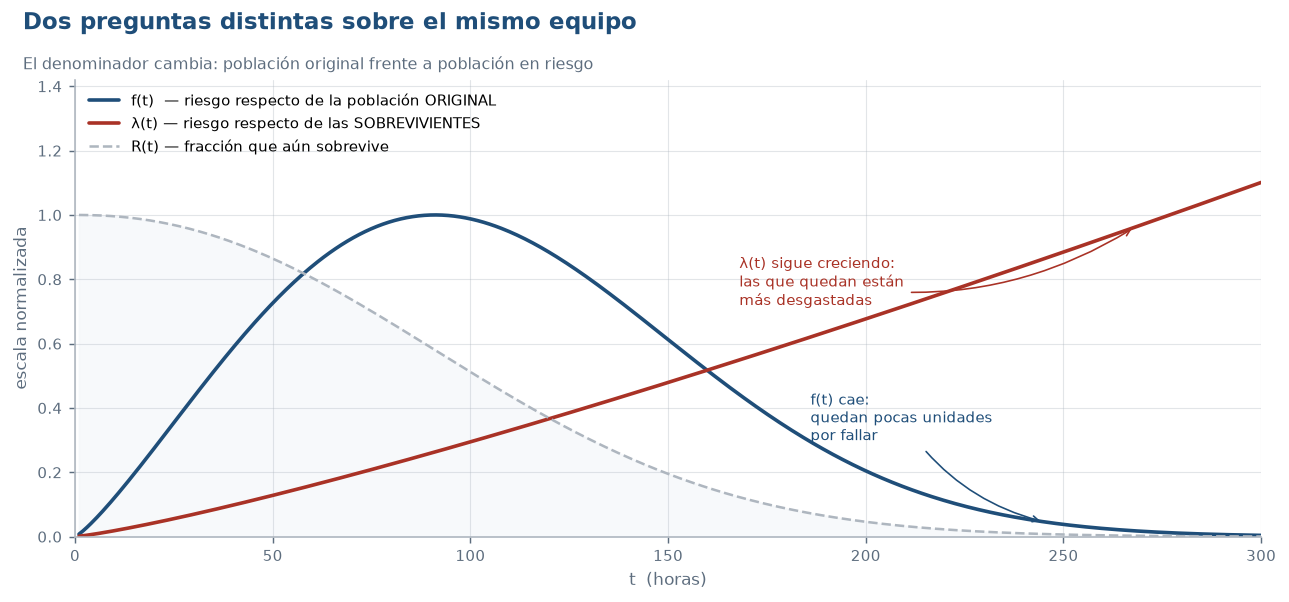

A las 250 h ya falló el 99.3% de la población: f(t) es baja porque queda poco por fallar.
Pero para una unidad que SIGUE operando a las 250 h, el riesgo es el más alto de su vida.

La decisión de mantenimiento se toma sobre equipos vivos -> se usa λ(t).


In [9]:
t = np.linspace(1, 300, 600)
fig, ax = plt.subplots(figsize=(9.8, 4.0))

ax.plot(t, M.pdf(t) / M.pdf(t).max(), color=PAL["azul"],
        label="f(t)  — riesgo respecto de la población ORIGINAL")
ax.plot(t, ((BETA/ETA)*(t/ETA)**(BETA-1)) / .05, color=PAL["rojo"],
        label="λ(t) — riesgo respecto de las SOBREVIVIENTES")
ax.plot(t, M.sf(t), color=PAL["grisc"], ls="--", lw=1.4,
        label="R(t) — fracción que aún sobrevive")
ax.fill_between(t, 0, M.sf(t), color=PAL["fondo"], alpha=.7, zorder=0)
ax.set_xlabel("t  (horas)"); ax.set_ylabel("escala normalizada")
ax.set_ylim(0, 1.42); ax.set_xlim(0, 300)
ax.legend(loc="upper left", fontsize=8.4)
anota(ax, "f(t) cae:\nquedan pocas unidades\npor fallar",
      (245, M.pdf(245) / M.pdf(t).max()), (186, .30), PAL["azul"])
anota(ax, "λ(t) sigue creciendo:\nlas que quedan están\nmás desgastadas",
      (268, ((BETA/ETA)*(268/ETA)**(BETA-1))/.05), (168, .72), PAL["rojo"])

titulo(fig, "Dos preguntas distintas sobre el mismo equipo",
       "El denominador cambia: población original frente a población en riesgo")
plt.show()

print("A las 250 h ya falló el "
      f"{M.cdf(250):.1%} de la población: f(t) es baja porque queda poco por fallar.")
print("Pero para una unidad que SIGUE operando a las 250 h, el riesgo es el más alto de su vida.")
print("\nLa decisión de mantenimiento se toma sobre equipos vivos -> se usa λ(t).")

---
## 7 · Distribuciones de vida más usadas

ReliaSoft define **distribuciones de vida** como el conjunto de distribuciones de probabilidad
que se usan en ingeniería de confiabilidad y análisis de datos de vida. Una distribución
estadística queda **completamente descrita por su pdf**: de ahí se derivan la confiabilidad, la
tasa de fallas, la vida media y la vida mediana.

Estas distribuciones fueron formuladas por estadísticos, matemáticos e ingenieros para modelar
matemáticamente ciertos comportamientos; algunas representan mejor los datos de vida y por eso
se denominan *lifetime distributions*.

### La receta general

Dada la pdf, el resto es mecánico. ReliaSoft lo ilustra con la exponencial:

$$f(t)=\lambda e^{-\lambda t}
\;\Longrightarrow\;
R(t)=\int_t^\infty \lambda e^{-\lambda s}ds=e^{-\lambda t}
\;\Longrightarrow\;
\lambda(t)=\frac{f(t)}{R(t)}=\lambda
\;\Longrightarrow\;
\text{MTTF}=\frac{1}{\lambda}$$

**La misma metodología se aplica a cualquier distribución**, con distinto grado de dificultad
según la complejidad de $f(t)$.

### Las cuatro principales

| Distribución | pdf | Parámetros | Cuándo usarla |
|---|---|---|---|
| **Exponencial** | $\lambda e^{-\lambda t}$ | $\lambda$ (escala) | Tasa de fallas **constante**; sin desgaste |
| **Weibull** | $\frac{\beta}{\eta}\left(\frac{t}{\eta}\right)^{\beta-1}e^{-(t/\eta)^\beta}$ | $\beta$ (forma), $\eta$ (escala), $\gamma$ (localización) | Uso general; $\beta$ codifica el mecanismo |
| **Lognormal** | $\frac{1}{t\sigma'\sqrt{2\pi}}e^{-\frac{(\ln t-\mu')^2}{2\sigma'^2}}$ | $\mu'$, $\sigma'$ (de $\ln T$) | Daño acumulativo multiplicativo; **tiempos de reparación** |
| **Normal** | $\frac{1}{\sigma\sqrt{2\pi}}e^{-\frac{(t-\mu)^2}{2\sigma^2}}$ | $\mu$ (media), $\sigma$ (desv.) | Desgaste puro con poca dispersión |

**Nota sobre la exponencial.** ReliaSoft la describe como una de las distribuciones más simples
y usadas, y advierte que con frecuencia se **sobreutiliza erróneamente por su simplicidad**. Es
un caso particular de la Weibull con $\beta=1$.

**Nota sobre la normal.** Su recorrido es $(-\infty,\infty)$, así que asigna probabilidad
positiva a tiempos negativos. ReliaSoft señala que, salvo la normal, el rango de las
distribuciones de vida consideradas es $[0,\infty)$. Es usable solo si $\mu/\sigma$ es
suficientemente grande para que esa masa sea despreciable.

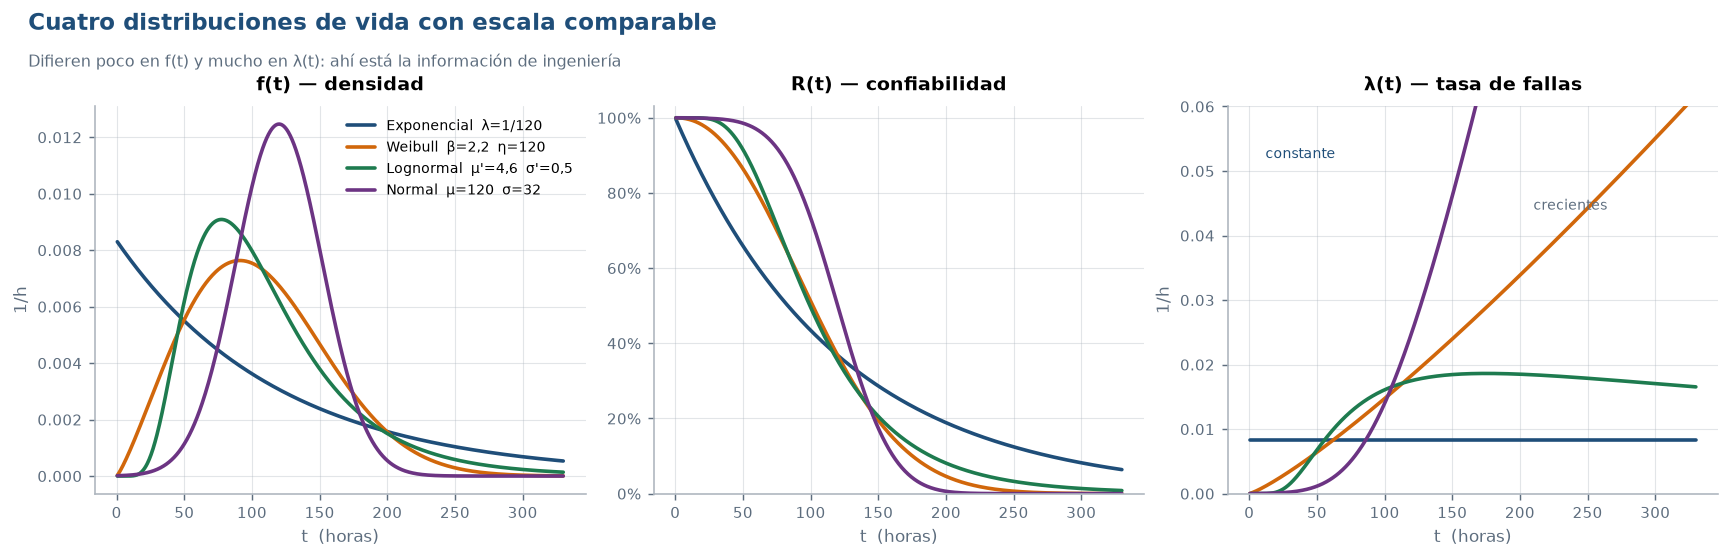

,MTTF (h),Mediana (h),Desv. est. (h),CV,B10 (h),R(200 h)
Distribución,,,,,,
Exponencial λ=1/120,120.000,83.178,120.000,1.000,12.643,0.189
"Weibull β=2,2 η=120",106.275,101.585,50.994,0.480,43.146,0.046
"Lognormal μ'=4,6 σ'=0,5",112.730,99.484,60.079,0.533,52.417,0.081
Normal μ=120 σ=32,120.000,120.000,32.000,0.267,78.990,0.006


MTTF casi idénticos; B10 va de 12,6 h a 79 h  ->  el MTTF no distingue lo que importa.


In [10]:
DIST = {
    "Exponencial  λ=1/120":      (stats.expon(scale=120),               PAL["azul"]),
    "Weibull  β=2,2  η=120":     (stats.weibull_min(2.2, scale=120),    PAL["naranja"]),
    "Lognormal  μ'=4,6  σ'=0,5": (stats.lognorm(0.5, scale=np.exp(4.6)), PAL["verde"]),
    "Normal  μ=120  σ=32":       (stats.norm(120, 32),                  PAL["morado"]),
}

t = np.linspace(0.5, 330, 700)
fig, ax = plt.subplots(1, 3, figsize=(13.2, 3.7))
for nom, (d, col) in DIST.items():
    ax[0].plot(t, d.pdf(t), color=col, label=nom)
    ax[1].plot(t, d.sf(t),  color=col, label=nom)
    ax[2].plot(t, d.pdf(t) / np.maximum(d.sf(t), 1e-12), color=col, label=nom)

ax[0].set_title("f(t) — densidad"); ax[0].set_ylabel("1/h")
ax[1].set_title("R(t) — confiabilidad"); ax[1].set_ylim(0, 1.03)
ax[1].yaxis.set_major_formatter(PercentFormatter(1.0))
ax[2].set_title("λ(t) — tasa de fallas"); ax[2].set_ylim(0, .06); ax[2].set_ylabel("1/h")
ax[2].text(12, .052, "constante", color=PAL["azul"], fontsize=8)
ax[2].text(210, .044, "crecientes", color=PAL["gris"], fontsize=8)
for a in ax:
    a.set_xlabel("t  (horas)")
ax[0].legend(loc="upper right", fontsize=7.8)

titulo(fig, "Cuatro distribuciones de vida con escala comparable",
       "Difieren poco en f(t) y mucho en λ(t): ahí está la información de ingeniería")
plt.show()

res = pd.DataFrame([{
    "Distribución": nom, "MTTF (h)": d.mean(), "Mediana (h)": d.median(),
    "Desv. est. (h)": d.std(), "CV": d.std() / d.mean(),
    "B10 (h)": d.ppf(.10), "R(200 h)": d.sf(200),
} for nom, (d, _) in DIST.items()]).set_index("Distribución")
display(res.round(3))

print("MTTF casi idénticos; B10 va de 12,6 h a 79 h  ->  el MTTF no distingue lo que importa.")

### El parámetro de forma de la Weibull y su lectura física

ReliaSoft describe la Weibull como una de las distribuciones de vida más usadas y **versátil,
capaz de adoptar las características de otros tipos de distribución según el valor del parámetro
de forma $\beta$**. Esa versatilidad es la razón de su dominio en la práctica.

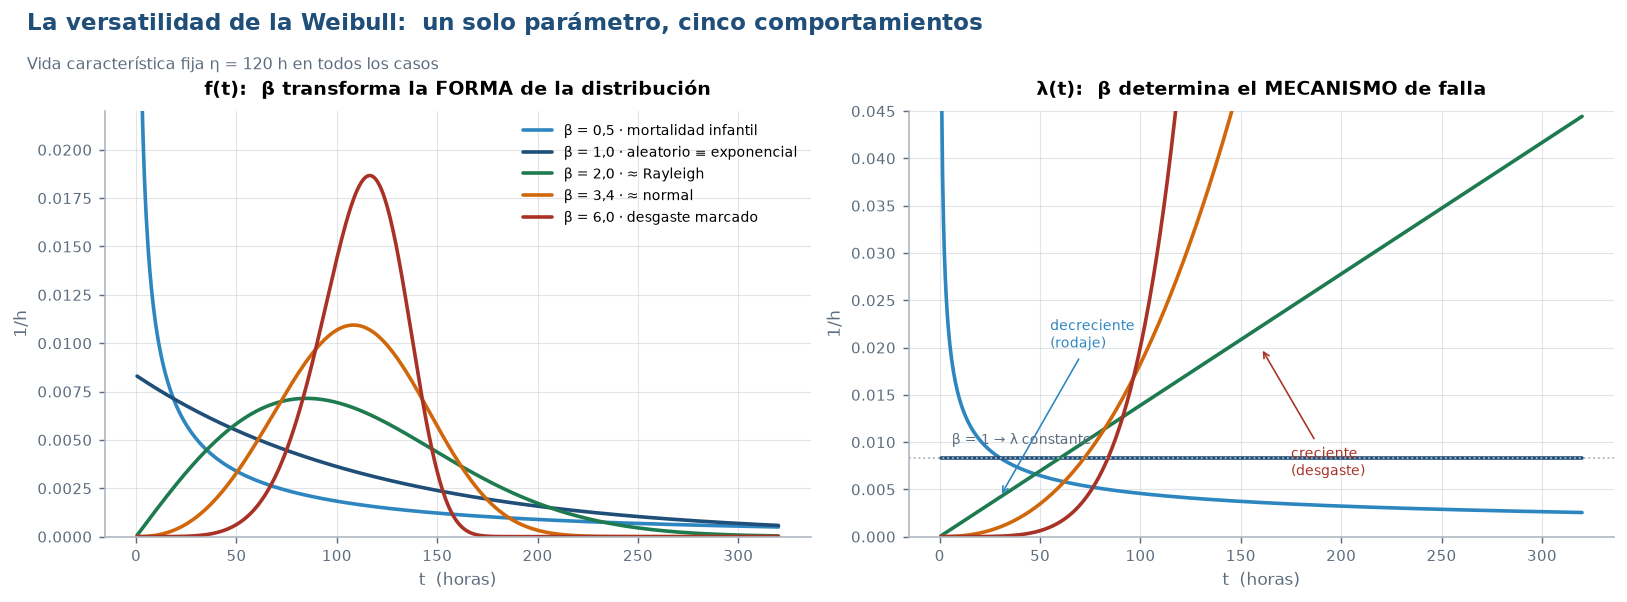

    β |  MTTF (h) |  B10 (h) |     CV | interpretación
------------------------------------------------------------------------
  0.5 |     240.0 |      1.3 |  2.236 | mortalidad infantil
  1.0 |     120.0 |     12.6 |  1.000 | aleatorio ≡ exponencial
  2.0 |     106.3 |     39.0 |  0.523 | ≈ Rayleigh
  3.4 |     107.8 |     61.9 |  0.325 | ≈ normal
  6.0 |     111.3 |     82.5 |  0.194 | desgaste marcado

Misma η = 120 h para todos, pero el B10 va de 1,2 h a 78 h: 65 veces.
Reportar solo η —o solo el MTTF— oculta por completo esa diferencia.


In [11]:
t = np.linspace(0.5, 320, 700)
ETA0 = 120.0
CASOS = [(0.5, "β = 0,5", PAL["celeste"], "mortalidad infantil"),
         (1.0, "β = 1,0", PAL["azul"],    "aleatorio ≡ exponencial"),
         (2.0, "β = 2,0", PAL["verde"],   "≈ Rayleigh"),
         (3.4, "β = 3,4", PAL["naranja"], "≈ normal"),
         (6.0, "β = 6,0", PAL["rojo"],    "desgaste marcado")]

fig, ax = plt.subplots(1, 2, figsize=(12.4, 4.0))
for b, lab, col, nota in CASOS:
    d = stats.weibull_min(b, scale=ETA0)
    ax[0].plot(t, d.pdf(t), color=col, label=f"{lab} · {nota}")
    ax[1].plot(t, (b / ETA0) * (t / ETA0) ** (b - 1), color=col, label=lab)

ax[0].set_title("f(t):  β transforma la FORMA de la distribución")
ax[0].set_ylim(0, .022); ax[0].set_ylabel("1/h"); ax[0].legend(fontsize=8)
ax[1].set_title("λ(t):  β determina el MECANISMO de falla")
ax[1].set_ylim(0, .045); ax[1].set_ylabel("1/h")
ax[1].axhline((1/ETA0), color=PAL["grisc"], ls=":", lw=1)
ax[1].text(6, .0098, "β = 1 → λ constante", fontsize=8, color=PAL["gris"])
ax[1].annotate("decreciente\n(rodaje)", xy=(30, .0042), xytext=(55, .020),
               fontsize=8, color=PAL["celeste"],
               arrowprops=dict(arrowstyle="->", color=PAL["celeste"], lw=.9))
ax[1].annotate("creciente\n(desgaste)", xy=(160, .020), xytext=(175, .0065),
               fontsize=8, color=PAL["rojo"],
               arrowprops=dict(arrowstyle="->", color=PAL["rojo"], lw=.9))
for a in ax:
    a.set_xlabel("t  (horas)")

titulo(fig, "La versatilidad de la Weibull:  un solo parámetro, cinco comportamientos",
       f"Vida característica fija η = {ETA0:.0f} h en todos los casos")
plt.show()

print(f"{'β':>5} | {'MTTF (h)':>9} | {'B10 (h)':>8} | {'CV':>6} | interpretación")
print("-" * 72)
for b, lab, _, nota in CASOS:
    d = stats.weibull_min(b, scale=ETA0)
    print(f"{b:>5.1f} | {d.mean():>9.1f} | {d.ppf(.1):>8.1f} | "
          f"{d.std()/d.mean():>6.3f} | {nota}")
print(f"\nMisma η = {ETA0:.0f} h para todos, pero el B10 va de 1,2 h a 78 h: 65 veces.")
print("Reportar solo η —o solo el MTTF— oculta por completo esa diferencia.")

---
## 8 · Parámetros: escala, forma y localización

ReliaSoft es explícito: las distribuciones pueden tener cualquier número de parámetros, pero
**a medida que el número de parámetros aumenta, también lo hace la cantidad de datos requerida
para un ajuste adecuado**. En la práctica, las distribuciones de vida se limitan a un máximo de
tres: escala, forma y localización.

### 8.1 Parámetro de escala ($\eta$, $\lambda$, $\sigma$)

Es **el tipo más común**: todas las distribuciones de la referencia tienen uno, y en las
distribuciones de un solo parámetro, ese único parámetro **es** el de escala.

Define **dónde se sitúa el grueso de la distribución** sobre el eje de tiempos: la estira o la
comprime sin cambiar su forma. Cambiar la escala equivale a **cambiar de unidad de medida**
—de horas a días, por ejemplo—. Formalmente, si $T$ tiene escala $\eta$, entonces $cT$ tiene
escala $c\eta$ y **la misma forma**.

### 8.2 Parámetro de forma ($\beta$, $\sigma'$)

Cambia **la forma misma** de la distribución: su asimetría, su curtosis y —lo decisivo en
confiabilidad— **el comportamiento de $\lambda(t)$**. No se puede compensar con un cambio de
unidades. Es el parámetro que codifica la **física del mecanismo de falla**.

La exponencial **no tiene parámetro de forma**: su forma es siempre la misma.

### 8.3 Parámetro de localización ($\gamma$)

Desplaza la distribución a lo largo del eje sin alterar forma ni escala. En la Weibull se
denomina $\gamma$ y se interpreta como **vida libre de fallas** (*failure free life*).

Para la exponencial de dos parámetros, ReliaSoft precisa la interpretación: el parámetro de
localización, **si es positivo, desplaza el inicio de la distribución una distancia $\gamma$ a la
derecha del origen, lo que significa que las fallas por azar comienzan a ocurrir solo después de
$\gamma$ horas de operación, y no pueden ocurrir antes**.

> **Advertencia de ingeniería.** Un $\gamma>0$ es una afirmación fuerte: sostiene que **ninguna
> unidad puede fallar** antes de ese tiempo. Debe justificarse físicamente (un periodo de
> incubación, un umbral de desgaste acumulado), no adoptarse solo porque mejora el ajuste. Un
> $\gamma$ negativo indica que las unidades ya habían acumulado daño antes de entrar en
> servicio —almacenamiento, transporte, pruebas previas.

/home/gonzase1@SIERRACOL.LOCAL/.local/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:2760: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


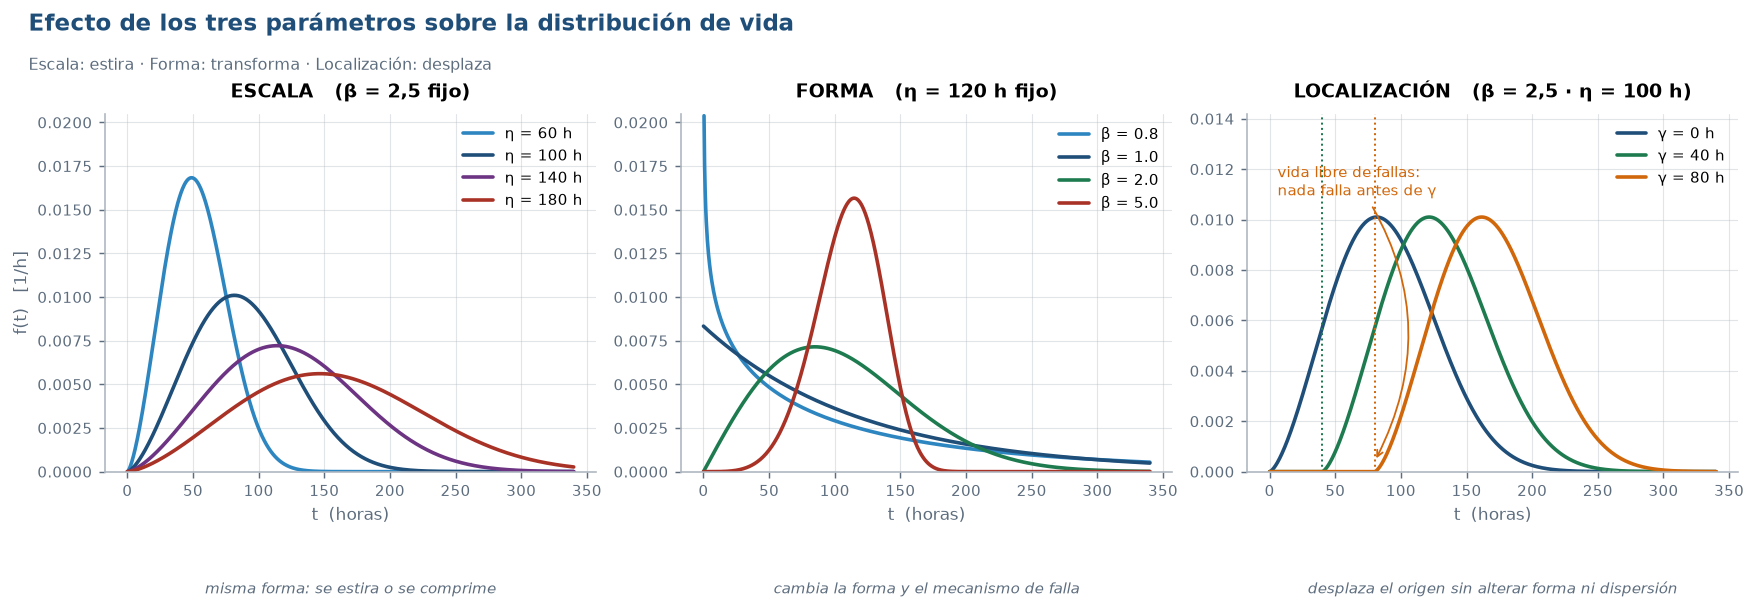

ESCALA — la forma se conserva; solo cambia la unidad de tiempo efectiva
   η= 60 h -> MTTF=  53.2 h | CV=0.4279 | asimetría=0.3586
   η=120 h -> MTTF= 106.5 h | CV=0.4279 | asimetría=0.3586
   El CV y la asimetría NO cambian: son invariantes de escala.

FORMA — cambian la asimetría, el CV y el mecanismo de falla
   β=0.8   -> MTTF= 136.0 h | CV=1.2605 | asimetría=+2.8146
   β=2.5   -> MTTF= 106.5 h | CV=0.4279 | asimetría=+0.3586

LOCALIZACIÓN — todo se desplaza γ horas; la dispersión es idéntica
   γ=  0 h -> MTTF=  88.7 h | desv.est.=37.967 h | B10=  40.7 h
   γ= 80 h -> MTTF= 168.7 h | desv.est.=37.967 h | B10= 120.7 h
   La desviación estándar es la misma: γ no afecta la dispersión.


In [12]:
t = np.linspace(0, 340, 800)
fig, ax = plt.subplots(1, 3, figsize=(13.4, 4.0))

# ---------- ESCALA: varía η, β fijo
for eta, col in zip([60, 100, 140, 180], [PAL["celeste"], PAL["azul"],
                                          PAL["morado"], PAL["rojo"]]):
    ax[0].plot(t, stats.weibull_min.pdf(t, 2.5, scale=eta), color=col,
               label=f"η = {eta} h")
ax[0].set_title("ESCALA   (β = 2,5 fijo)")
ax[0].set_ylabel("f(t)   [1/h]")
ax[0].set_ylim(0, .0205)
ax[0].legend(loc="upper right", fontsize=8.2)
ax[0].text(.5, -.34, "misma forma: se estira o se comprime",
           transform=ax[0].transAxes, fontsize=8.4, ha="center",
           color=PAL["gris"], style="italic")

# ---------- FORMA: varía β, η fijo
for b, col in zip([0.8, 1.0, 2.0, 5.0], [PAL["celeste"], PAL["azul"],
                                         PAL["verde"], PAL["rojo"]]):
    ax[1].plot(t, stats.weibull_min.pdf(t, b, scale=120), color=col,
               label=f"β = {b}")
ax[1].set_title("FORMA   (η = 120 h fijo)")
ax[1].set_ylim(0, .0205)
ax[1].legend(loc="upper right", fontsize=8.2)
ax[1].text(.5, -.34, "cambia la forma y el mecanismo de falla",
           transform=ax[1].transAxes, fontsize=8.4, ha="center",
           color=PAL["gris"], style="italic")

# ---------- LOCALIZACIÓN: varía γ
for g, col in zip([0, 40, 80], [PAL["azul"], PAL["verde"], PAL["naranja"]]):
    ax[2].plot(t, stats.weibull_min.pdf(t, 2.5, loc=g, scale=100), color=col,
               label=f"γ = {g} h")
    if g > 0:
        ax[2].axvline(g, color=col, ls=":", lw=1.1)
ax[2].set_title("LOCALIZACIÓN   (β = 2,5 · η = 100 h)")
ax[2].set_ylim(0, .0142)
ax[2].legend(loc="upper right", fontsize=8.2)
ax[2].annotate("vida libre de fallas:\nnada falla antes de γ",
               xy=(80, .0004), xytext=(6, .0122), fontsize=8.4,
               color=PAL["naranja"], va="top",
               arrowprops=dict(arrowstyle="->", color=PAL["naranja"], lw=1,
                               connectionstyle="arc3,rad=-.3"))
ax[2].text(.5, -.34, "desplaza el origen sin alterar forma ni dispersión",
           transform=ax[2].transAxes, fontsize=8.4, ha="center",
           color=PAL["gris"], style="italic")

for a in ax:
    a.set_xlabel("t  (horas)")

titulo(fig, "Efecto de los tres parámetros sobre la distribución de vida",
       "Escala: estira · Forma: transforma · Localización: desplaza")
plt.show()

print("ESCALA — la forma se conserva; solo cambia la unidad de tiempo efectiva")
for eta in (60, 120):
    d = stats.weibull_min(2.5, scale=eta)
    print(f"   η={eta:3d} h -> MTTF={d.mean():6.1f} h | CV={d.std()/d.mean():.4f}"
          f" | asimetría={float(d.stats('s')):.4f}")
print("   El CV y la asimetría NO cambian: son invariantes de escala.\n")

print("FORMA — cambian la asimetría, el CV y el mecanismo de falla")
for b in (0.8, 2.5):
    d = stats.weibull_min(b, scale=120)
    print(f"   β={b:.1f}   -> MTTF={d.mean():6.1f} h | CV={d.std()/d.mean():.4f}"
          f" | asimetría={float(d.stats('s')):+.4f}")

print("\nLOCALIZACIÓN — todo se desplaza γ horas; la dispersión es idéntica")
for g in (0, 80):
    d = stats.weibull_min(2.5, loc=g, scale=100)
    print(f"   γ={g:3d} h -> MTTF={d.mean():6.1f} h | desv.est.={d.std():.3f} h"
          f" | B10={d.ppf(.1):6.1f} h")
print("   La desviación estándar es la misma: γ no afecta la dispersión.")

### 8.4 El costo de añadir parámetros

La advertencia de ReliaSoft sobre los datos requeridos merece una demostración. Añadir $\gamma$
casi siempre **mejora el ajuste** —un parámetro libre adicional nunca empeora la
verosimilitud—, pero con muestras pequeñas ese ajuste puede ser **puro ruido**, y el $\gamma$
estimado se convierte en una afirmación física falsa: que existe un periodo garantizado sin
fallas que en realidad no existe.

,γ mediana (h),γ P5 (h),γ P95 (h),P(γ̂ > 10 h)
n,,,,
10,25.17,-6.683590e+08,65.13,0.65
20,16.10,-6.865000e+01,51.32,0.58
50,8.38,-2.055000e+01,34.09,0.44
150,2.75,-9.310000e+00,18.50,0.18
500,1.36,-3.480000e+00,9.70,0.05


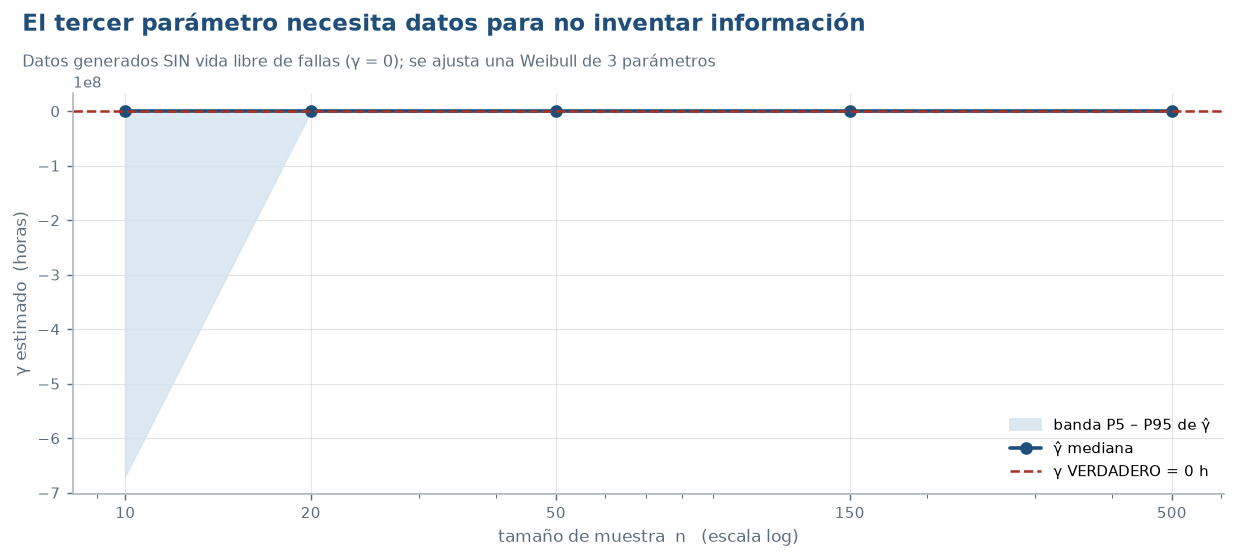

Los datos NO tienen vida libre de fallas: γ verdadero = 0 h.
Con n = 10, el 65% de las muestras estima γ̂ > 10 h
y concluiría, falsamente, que el equipo no puede fallar en sus primeras 10 horas.

Regla práctica: no añada el parámetro de localización sin (a) muestra amplia
y (b) un mecanismo físico que justifique el periodo sin fallas.


In [13]:
g = np.random.default_rng(2026)
filas = []
for n in (10, 20, 50, 150, 500):
    gam = []
    for _ in range(400):
        # VERDAD: Weibull de 2 parámetros -> gamma verdadero = 0
        x = stats.weibull_min.rvs(2.2, scale=120, size=n, random_state=g)
        try:
            b3, g3, e3 = stats.weibull_min.fit(x)      # ajuste de 3 parámetros
            gam.append(g3)
        except Exception:
            pass
    gam = np.array(gam)
    filas.append({"n": n, "γ mediana (h)": np.median(gam),
                  "γ P5 (h)": np.percentile(gam, 5),
                  "γ P95 (h)": np.percentile(gam, 95),
                  "P(γ̂ > 10 h)": np.mean(gam > 10)})
d3 = pd.DataFrame(filas).set_index("n")
display(d3.round(2))

fig, ax = plt.subplots(figsize=(9.4, 3.7))
ax.fill_between(d3.index, d3["γ P5 (h)"], d3["γ P95 (h)"],
                color=PAL["relleno"], alpha=.85, label="banda P5 – P95 de γ̂")
ax.plot(d3.index, d3["γ mediana (h)"], "o-", color=PAL["azul"], label="γ̂ mediana")
ax.axhline(0, color=PAL["rojo"], ls="--", lw=1.4, label="γ VERDADERO = 0 h")
ax.set_xscale("log"); ax.set_xlabel("tamaño de muestra  n   (escala log)")
ax.set_ylabel("γ estimado  (horas)"); ax.legend(loc="lower right")
ax.set_xticks(d3.index); ax.set_xticklabels(d3.index)

titulo(fig, "El tercer parámetro necesita datos para no inventar información",
       "Datos generados SIN vida libre de fallas (γ = 0); se ajusta una Weibull de 3 parámetros")
plt.show()

print("Los datos NO tienen vida libre de fallas: γ verdadero = 0 h.")
print(f"Con n = 10, el {d3.loc[10, 'P(γ̂ > 10 h)']:.0%} de las muestras estima γ̂ > 10 h")
print("y concluiría, falsamente, que el equipo no puede fallar en sus primeras 10 horas.")
print("\nRegla práctica: no añada el parámetro de localización sin (a) muestra amplia")
print("y (b) un mecanismo físico que justifique el periodo sin fallas.")

---
## 9 · Síntesis

### El mapa completo

```
                    ┌─────────────────────────────────────┐
                    │   Variable aleatoria  T ≥ 0         │
                    │   (tiempo hasta la falla)           │
                    └──────────────────┬──────────────────┘
                                       │
                          se describe con su densidad
                                       │
                                    f(t)
                                       │
              ┌────────────────────────┼────────────────────────┐
              │                        │                        │
          ∫₀ᵗ f(s)ds              ∫ₜ^∞ f(s)ds              f(t) / R(t)
              │                        │                        │
            Q(t)  ◄──── 1 − R(t) ───►  R(t)                   λ(t)
        infiabilidad              confiabilidad          tasa de fallas
                                       │                        │
                                  ∫₀^∞ R(t)dt          R(t) = e^(−∫λ)
                                       │
                                     MTTF
```

### Ideas que conviene retener

1. **La pdf lo determina todo.** Conocida $f(t)$, se obtienen $Q(t)$, $R(t)$, $\lambda(t)$,
   MTTF y vida mediana por integración, complemento o cociente.

2. **La probabilidad es área, no altura.** $f(t)$ y $\lambda(t)$ tienen unidades de
   $1/\text{tiempo}$ y pueden exceder 1; no son probabilidades.

3. **$R(t)$ exige un tiempo.** "95 % a 100 horas" es una especificación; "MTTF = 106 horas"
   resume toda la curva en un punto y oculta dónde están las fallas.

4. **$\lambda(t)$ es condicional.** Se calcula sobre las unidades que siguen vivas, que es
   exactamente la población sobre la que se decide mantener o reemplazar.

5. **La media es frágil.** Un solo valor extremo la desplaza sin límite. Reportar media,
   mediana, dispersión y $n$ —no una sola cifra.

6. **La forma importa más que la escala.** Distribuciones con el mismo MTTF pueden tener $B_{10}$
   que difieren en un orden de magnitud. El parámetro de forma codifica el mecanismo físico.

7. **Cada parámetro extra cuesta datos.** El parámetro de localización exige muestra amplia y
   justificación física; de lo contrario, inventa un periodo sin fallas inexistente.

---

## Referencias

1. **ReliaSoft.** *Basic statistical background*. Life Data Analysis Reference. HBK World.
   https://help.reliasoft.com/reference/life_data_analysis/lda/basic_statistical_background.html

2. **ReliaSoft.** *Life distributions*. Life Data Analysis Reference. HBK World.
   https://help.reliasoft.com/reference/life_data_analysis/lda/life_distributions.html

3. **ReliaSoft.** *The Weibull distribution*. Life Data Analysis Reference. HBK World.
   https://help.reliasoft.com/reference/life_data_analysis/lda/the_weibull_distribution.html

4. **ReliaSoft.** *The exponential distribution*. Life Data Analysis Reference. HBK World.
   https://help.reliasoft.com/reference/life_data_analysis/lda/the_exponential_distribution.html

5. **Kececioglu, D.** (1993). *Reliability and life testing handbook* (Vol. 1). Prentice Hall.
   *(Fuente de las caracterizaciones de los parámetros citadas por ReliaSoft.)*

6. **Meeker, W. Q., Escobar, L. A., y Pascual, F. G.** (2022). *Statistical methods for
   reliability data* (2.ª ed.). Wiley.

7. **National Institute of Standards and Technology.** (2012). *NIST/SEMATECH e-handbook of
   statistical methods*. https://doi.org/10.18434/M32189

8. **Nelson, W.** (1982). *Applied life data analysis*. Wiley.

9. **Weibull, W.** (1951). A statistical distribution function of wide applicability. *Journal
   of Applied Mechanics, 18*(3), 293–297. https://doi.org/10.1115/1.4010337

---

### Alcance de la evidencia

Las fuentes respaldan las **definiciones, fórmulas y métodos** presentados. **No respaldan los
valores numéricos de los ejemplos**, que son simulaciones generadas en este cuaderno con
parámetros declarados y semilla fija (`20260912`). Ninguna cifra proviene de un activo o una
organización real. Cualquier aplicación a datos operativos exige validar el criterio de falla,
el reloj de exposición y la homogeneidad técnica de la población, con juicio de ingeniería.